In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt

In [15]:
shootings_df = pd.read_csv('shootings.csv')
philly_df = pd.read_csv('openphilly_data_shootings.csv')

In [17]:
## How much of all shootings come from just a few districts

shoot_dist = shootings_df["dist"].value_counts()
total = shoot_dist.sum()
top5_percent = shoot_dist.head(5).sum() / total * 100
shoot_dist.head(10)

dist
25.0    2111
22.0    1991
24.0    1716
35.0    1381
39.0    1314
15.0    1284
12.0    1269
19.0    1225
14.0     919
18.0     841
Name: count, dtype: int64

In [22]:
print(f'The total number of shootings that occured in top 5 ditrcits is {total}')
print(f'Percentage of all shootings that occurred in the top 5 districts is {top5_percent}')

The total number of shootings that occured in top 5 ditrcits is 17514
Percentage of all shootings that occurred in the top 5 districts is 48.60682882265616


In [25]:
shootings_df["wound"].value_counts().head()

wound
Multiple    5334
Leg         3314
Head        1484
Chest       1022
Arm          957
Name: count, dtype: int64

In [26]:
philly_df["wound"].value_counts().head()

wound
multi       1706
Multiple    1144
leg          976
Leg          717
head         557
Name: count, dtype: int64

In [28]:
shootings_df["wound"] = shootings_df["wound"].str.lower()
philly_df["wound"] = philly_df["wound"].str.lower()

In [30]:
shootings_df["wound"] = shootings_df["wound"].replace("multi", "multiple")
philly_df["wound"] = philly_df["wound"].replace("multi", "multiple")

In [36]:
shoot_wound_pct = shootings_df["wound"].value_counts(normalize=True) * 100
philly_wound_pct = philly_df["wound"].value_counts(normalize=True) * 100

shoot_wound_pct.head()

wound
multiple    30.904581
leg         19.464636
head         8.745817
chest        5.982462
arm          5.670936
Name: proportion, dtype: float64

In [37]:
philly_wound_pct.head()

wound
multiple    27.173707
leg         16.205721
head         8.325440
arm          5.843910
chest        5.588180
Name: proportion, dtype: float64

In [53]:
diff = shoot_wound_pct.head() - philly_wound_pct.head()
print(diff)

wound
arm        -0.172974
chest       0.394283
head        0.420377
leg         3.258915
multiple    3.730873
Name: proportion, dtype: float64


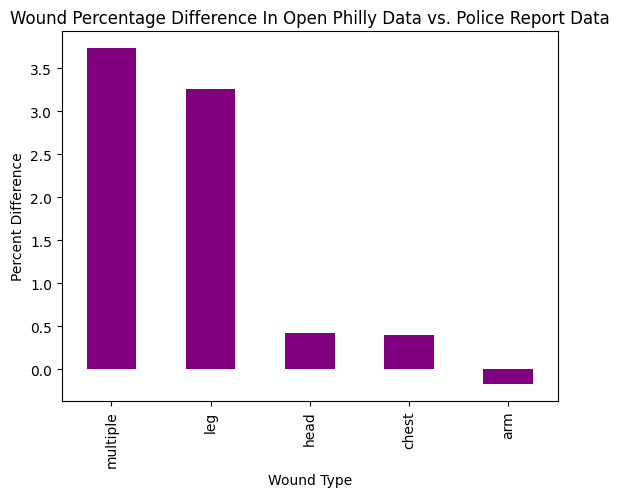

In [69]:
## A bar chart showing % of difference for each wound type for both datasets

diff.sort_values(ascending=False).plot(kind="bar",color="purple")

plt.title("Wound Percentage Difference In Open Philly Data vs. Police Report Data")
plt.xlabel("Wound Type")
plt.ylabel("Percent Difference")
plt.xticks(rotation=90)

plt.show()

In [70]:
shootings_df.columns 

Index(['the_geom', 'the_geom_webmercator', 'objectid', 'year', 'dc_key',
       'code', 'date_', 'time', 'race', 'sex', 'age', 'wound',
       'officer_involved', 'offender_injured', 'offender_deceased', 'location',
       'latino', 'point_x', 'point_y', 'dist', 'inside', 'outside', 'fatal',
       'lat', 'lng'],
      dtype='str')

In [71]:
philly_df.columns

Index(['the_geom', 'the_geom_webmercator', 'objectid', 'year', 'dc_key',
       'code', 'date_', 'time', 'race', 'sex', 'age', 'wound',
       'officer_involved', 'offender_injured', 'offender_deceased', 'location',
       'latino', 'point_x', 'point_y', 'dist', 'inside', 'outside', 'fatal',
       'lat', 'lng'],
      dtype='str')

In [80]:
shoot_sex = shootings_df["sex"].value_counts().head()
print(shoot_sex)

sex
M    15608
F     1882
Name: count, dtype: int64


In [81]:
philly_sex = philly_df["sex"].value_counts().head()
print(philly_sex)

sex
M    9684
F     982
Name: count, dtype: int64


In [82]:
diff_sex = shoot_sex - philly_sex
print(diff_sex)

sex
M    5924
F     900
Name: count, dtype: int64


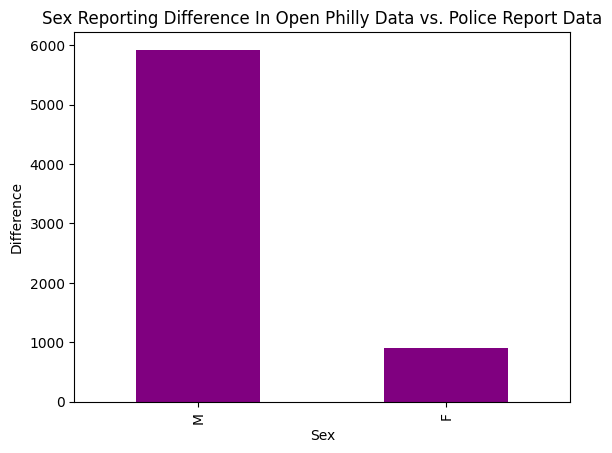

In [107]:
## A bar chart showing % of each wound type for both datasets

diff_sex.sort_values(ascending=False).plot(kind="bar",color="purple")

plt.title("Sex Reporting Difference In Open Philly Data vs. Police Report Data")
plt.xlabel("Sex")
plt.ylabel("Difference")
plt.xticks(rotation=90)

plt.show()

In [101]:
shoot_inside = shootings_df["inside"].value_counts()
print(shoot_inside)

inside
0.0    16219
1.0     1123
Name: count, dtype: int64


In [102]:
philly_inside = philly_df["inside"].value_counts()
print(philly_inside)

inside
0.0    10016
1.0      562
Name: count, dtype: int64


In [104]:
diff_inside = shoot_inside - philly_inside
print(diff_inside)

inside
0.0    6203
1.0     561
Name: count, dtype: int64


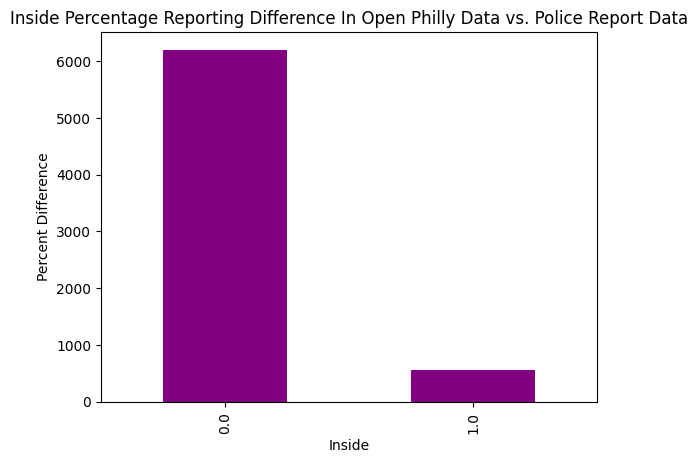

In [106]:
## A bar chart showing % of inside shots

diff_inside.plot(kind="bar",color="purple")

plt.title("Inside Percentage Reporting Difference In Open Philly Data vs. Police Report Data")
plt.xlabel("Inside")
plt.ylabel("Percent Difference")
plt.xticks(rotation=90)

plt.show()